In [2]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal
from scipy.ndimage import gaussian_filter1d

import seaborn as sns
# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd

na = np.array
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py
import os 
import pickle

In [26]:
# Overview of all possible recordings 
rec_table = pd.read_csv('/mnt/server_epl/SCN1A/R1648H-analysis/recordings-main2.csv',delimiter=';')
# Get channel mapping
file_name = '/mnt/server_epl/SCN1A/R1648H-export/20-3-25/slice2/2025-03-20T12-08-00McsRecording.h5'
channel_raw_data = McsPy.McsData.RawData(file_name)    
channels = []
channels_dict ={}
for i,ch_n in enumerate(list(channel_raw_data.recordings[0].analog_streams[0].channel_infos.keys())):
    channels.append(channel_raw_data.recordings[0].analog_streams[0].channel_infos[ch_n].label)#.recordings[0].segment_streams[0].segment_entity.keys()
    # channels_dict[int(i)]= channel_raw_data.recordings[0].analog_streams[0].channel_infos[i].label
    channels_dict[channel_raw_data.recordings[0].analog_streams[0].channel_infos[ch_n].label]= int(i)#

/tmp/ipykernel_5748/1547535556.py:2: DtypeWarning: Columns (4,15,16,23) have mixed types. Specify dtype option on import or set low_memory=False.
  rec_table = pd.read_csv('/mnt/server_epl/SCN1A/R1648H-analysis/recordings-main2.csv',delimiter=';')


Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (252, 3592000), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (252,), type "|V108">


In [27]:
rec_table

,date,mouse age,mouseID,slice,Valid,genotype,Sex,recording,protocol,duration,...,Unnamed: 16374,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
0,28.10.24,P14,1,slice1,True,wt,?,1.0,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,28.10.24,P14,1,slice1,True,wt,?,2.0,5-10-10,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28.10.24,P14,1,slice1,True,wt,?,3.0,5-10-10,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28.10.24,P14,1,slice2,True,wt,?,1.0,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28.10.24,P14,1,slice2,True,wt,?,2.0,5-10-10,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,26.3.25,P20,15,slice5,NaN,wt,male,NaN,10-40,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,26.3.25,P20,15,slice6,NaN,wt,male,1.0,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178,26.3.25,P20,15,slice6,NaN,wt,male,2.0,10-40,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179,26.3.25,P20,15,slice7,NaN,wt,male,NaN,5-10-10,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
#set img path 
events_all = []
gnt  = []
for i_num in range(180):
    rr = rec_table.iloc[i_num]
    region = 'ctx'
    rr.date
    rr.slice
    rr.protocol
    rec_n = rr.recording
    if rec_n>1:
        try:
            file_name = rec_table.iloc[i_num].file_name
            detected_events = pd.read_csv('data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
            durs = detected_events['intervals_end']-detected_events['intervals_start']
            events_all.extend(durs)
            gnt.extend([rr.genotype]*len(detected_events))
        except:
            continue



In [40]:
df = pd.DataFrame({'events_dur':events_all,'genotype':gnt})

In [41]:
df[df['events_dur']>20].groupby(['genotype']).describe()

events_dur                                                         \
              count       mean        std        min        25%        50%   
genotype                                                                     
mut            16.0  43.809280  20.087204  20.368572  27.649073  38.172672   
wt            101.0  49.461576  28.948819  21.039772  28.249720  39.570976   

                                 
                75%         max  
genotype                         
mut       60.595876   81.469649  
wt        60.068464  159.444685

In [ ]:
#WT:  61, 51 LVF
#Mut:           

<Axes: xlabel='genotype', ylabel='events_dur'>

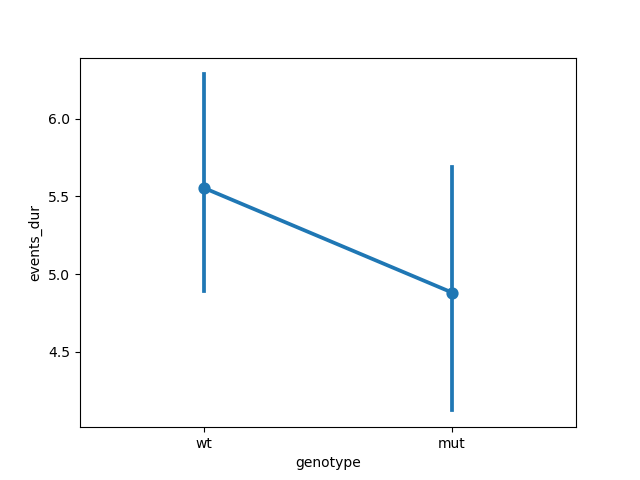

In [30]:
plt.figure()
sns.pointplot(x='genotype',y='events_dur',data=df)

In [110]:
print(np.sum(na(gnt)=='mut') )
print(np.sum(na(gnt)=='wt'))

444
856


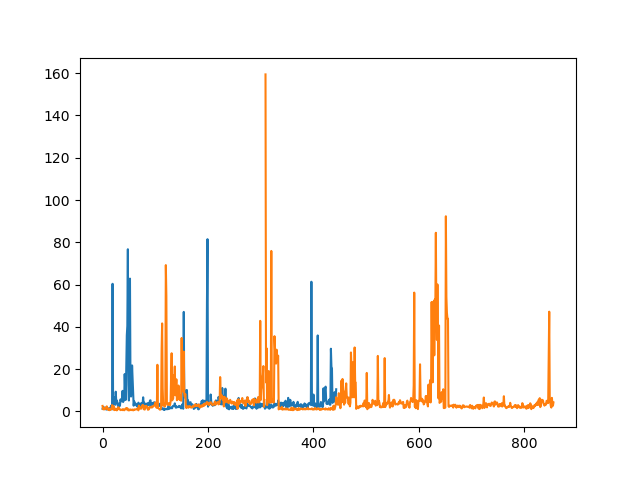

In [113]:
plt.figure()
plt.plot(na(events_all)[na(gnt)=='mut'])
plt.plot(na(events_all)[na(gnt)=='wt'])

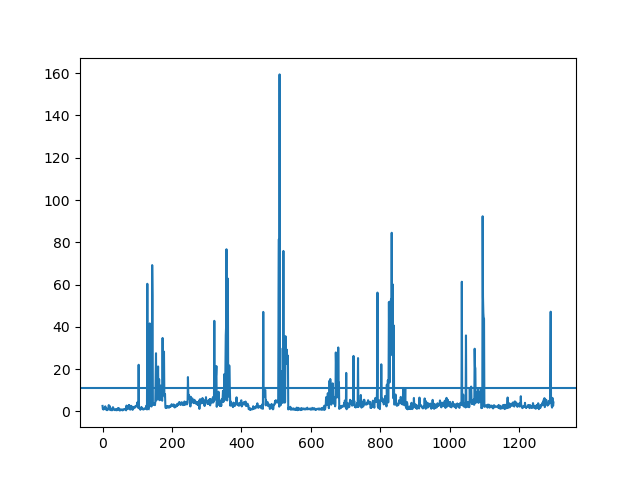

In [141]:
plt.figure()
plt.plot(events_all)
plt.axhline(11)

In [82]:
# np.sum(na(events_all)>10)
na(gnt)[na(events_all)>10]

array(['wt', 'mut', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut',
       'mut', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut', 'wt', 'wt',
       'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt', 'wt', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut', 'mut',
       'mut', 'mut', 'mut', 'mut', 'wt', 'wt', 'wt', 'wt', 'wt', 'wt',
       'wt', 'wt'], dtype='<U3')

In [ ]:
# load one event
for i_num in range(180):
    try:
        file_name = rec_table.iloc[i_num].file_name
        detected_events = pd.read_csv('data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
        from datetime import datetime
        path = rec_table.iloc[i_num].path.replace('\\','/')
        file_name = rec_table.iloc[i_num].file_name
        genotype = rec_table.iloc[i_num].genotype
        
        print('Protocol',rec_table.iloc[i_num].protocol,'Recording',rec_table.iloc[i_num].recording)
        os.path.join(path,file_name)
        slice_ =path.split('/')[-1]
        date =path.split('/')[0]
        dt = datetime.strptime(date, '%d-%m-%y')
        date = dt.strftime('%d-%m-%y')
        
        filt_file_name = 'R1648H_'+date+'_'+slice_+'_'+file_name+'.h5_filtered.h5'
        filt_path = '/mnt/server_epl/SCN1A/R1648H_filt'
        target_file = os.path.join(filt_path,filt_file_name).replace('\\','/')
        
        detection_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/labeled_electrodes.csv'
        detection_path =detection_path.replace('\\','/')
        ch_detection =pd.read_csv(detection_path)
        regions= na(ch_detection['region'])
        ch_labels = na(ch_detection['e_label'])
        valid_channels = [channels_dict[ch] for ch in ch_labels]
        valid_channels,ch_ind = np.unique(valid_channels,return_index=True)
        regions = regions[ch_ind]
        ch_labels = ch_labels[ch_ind]
        ch_srt_index = np.argsort(valid_channels)
        valid_channels = valid_channels[ch_srt_index]
        regions = regions[ch_srt_index]
        durs = detected_events['intervals_end']-detected_events['intervals_start']
        mv_scale_factor =  1000000
        ev_inds = np.where(durs>20)[0]
        all_events = []
        for ev_n in ev_inds:
            with h5py.File(target_file, 'r') as f:
                # print(f.keys())
                # print(f['data'].shape)
                subsampling_rate = na(f['resampled_rate'])
                adc_step = na(f['scale'])
                t0 = int(detected_events.iloc[ev_n].intervals_start *subsampling_rate)
                t1 = int(detected_events.iloc[ev_n].intervals_end*subsampling_rate)
                event = f['data'][t0:t1,valid_channels]*adc_step*mv_scale_factor
                all_events.append(event)
                if subsampling_rate!=800:
                    print(subsampling_rate)
        name = genotype+'_'+str(region)+'_'+file_name
        with open('data/exported_events/%s.pickle'%name, 'wb') as f:
            pickle.dump(all_events, f)
    except:
        continue

Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 4.0
1600
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
1600
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 2.0
1600
1600
1600
1600
Protocol 5-10-10 Recording 3.0
1600
1600
1600
1600
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
1600
1600
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 3.0
1600
1600
1600
1600
1600
1600
1600
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
1600
Protocol 5-10-10 Recording 4.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
1600
Protocol 5-10-10 Recording 

In [22]:
# Export Samples Rates
# load one event
all_rates,names = [],[]
for i_num in range(180):
    try:
        file_name = rec_table.iloc[i_num].file_name
        detected_events = pd.read_csv('data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
        from datetime import datetime
        path = rec_table.iloc[i_num].path.replace('\\','/')
        file_name = rec_table.iloc[i_num].file_name
        genotype = rec_table.iloc[i_num].genotype
        
        print('Protocol',rec_table.iloc[i_num].protocol,'Recording',rec_table.iloc[i_num].recording)
        os.path.join(path,file_name)
        slice_ =path.split('/')[-1]
        date =path.split('/')[0]
        dt = datetime.strptime(date, '%d-%m-%y')
        date = dt.strftime('%d-%m-%y')
        
        filt_file_name = 'R1648H_'+date+'_'+slice_+'_'+file_name+'.h5_filtered.h5'
        filt_path = 'data/R1648H_filt2'#'/mnt/server_epl/SCN1A/R1648H_filt'
        target_file = os.path.join(filt_path,filt_file_name).replace('\\','/')
        
        detection_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/labeled_electrodes.csv'
        detection_path =detection_path.replace('\\','/')
        ch_detection =pd.read_csv(detection_path)
        regions= na(ch_detection['region'])
        ch_labels = na(ch_detection['e_label'])
        valid_channels = [channels_dict[ch] for ch in ch_labels]
        valid_channels,ch_ind = np.unique(valid_channels,return_index=True)
        regions = regions[ch_ind]
        ch_labels = ch_labels[ch_ind]
        ch_srt_index = np.argsort(valid_channels)
        valid_channels = valid_channels[ch_srt_index]
        regions = regions[ch_srt_index]
        durs = detected_events['intervals_end']-detected_events['intervals_start']
        mv_scale_factor =  1000000
        ev_inds = np.where(durs>20)[0]
        all_events = []
        for ev_n in ev_inds:
            with h5py.File(target_file, 'r') as f:
                name = genotype+'_'+str(region)+'_'+file_name
                # print(f.keys())
                # print(f['data'].shape)
                subsampling_rate = na(f['resampled_rate'])
                # adc_step = na(f['scale'])
                # t0 = int(detected_events.iloc[ev_n].intervals_start *subsampling_rate)
                # t1 = int(detected_events.iloc[ev_n].intervals_end*subsampling_rate)
                # event = f['data'][t0:t1,valid_channels]*adc_step*mv_scale_factor
                all_rates.append(subsampling_rate)
                names.append(name)
                # if subsampling_rate!=800:
                #     print(subsampling_rate)
        # with open('data/exported_events/%s.pickle'%name, 'wb') as f:
        #     pickle.dump(all_events, f)
    except:
        
        continue

Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 4.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 4.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 3.0
Protocol 5-10-10 Recording 2.0
Protocol 5-10-10 Recording 1.0
Protocol 5-10-10 Recording 2.0
Protocol

In [23]:
event_meta = pd.DataFrame({'names':names,'subsampling_rate':all_rates})
# event_meta.to_csv('data/exported_events/events_meta')

In [24]:
np.unique(na(event_meta['subsampling_rate']))

array([array(1600)], dtype=object)

In [166]:
# name = genotype+'_'+str(region)+'_'+file_name
with open('data/exported_events/%s.pickle'%name, 'rb') as f:
    data = pickle.load(f)

In [168]:
len(data)

34

In [150]:
np.savez_compressed('data/exported_events/%s'%name, *all_events)
# name = genotype+str(region)+'_'+file_name
# with open('data/exported_events/%s.pickle'%name, 'wb') as f:
#     pickle.dump(all_events, f)

In [1]:
data = np.load('data/exported_events/%s.pickle.npz'%name)

NameError: name 'np' is not defined

In [157]:
data['arr_0'].shape

(10436, 149)

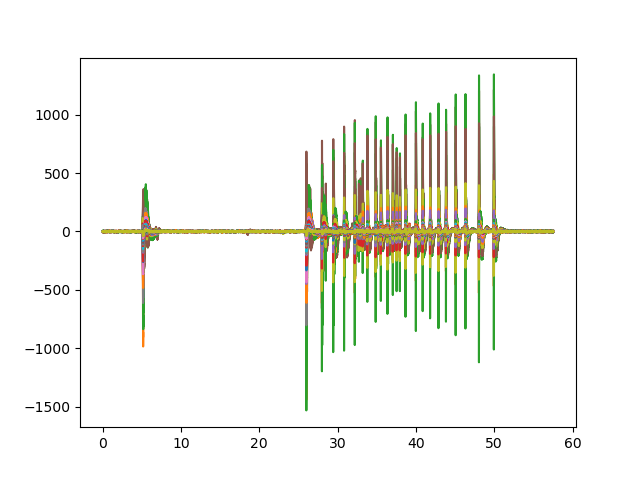

In [162]:
plt.figure()
plt.plot(np.arange(0,len(all_events[14]))*(1/subsampling_rate),all_events[14]);

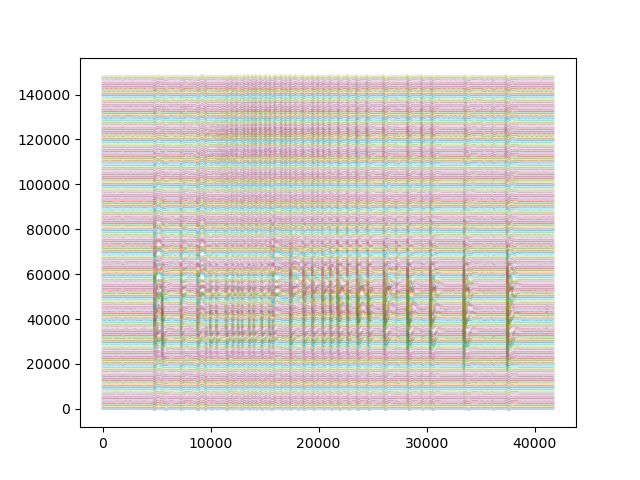

In [140]:
plt.figure()
y= all_events[13]#/np.max(filt[::subsplot,regions==region],0)#+np.arange(0,np.sum(regions==region))*300
y= y+np.arange(0,y.shape[1])*1000
plt.plot(y,alpha=0.3);

In [ ]:
plt.plot(all_events[13]);

In [73]:
durs = detected_events['intervals_end']-detected_events['intervals_start']

In [117]:
np.where(durs>10)[0]

array([43, 44])

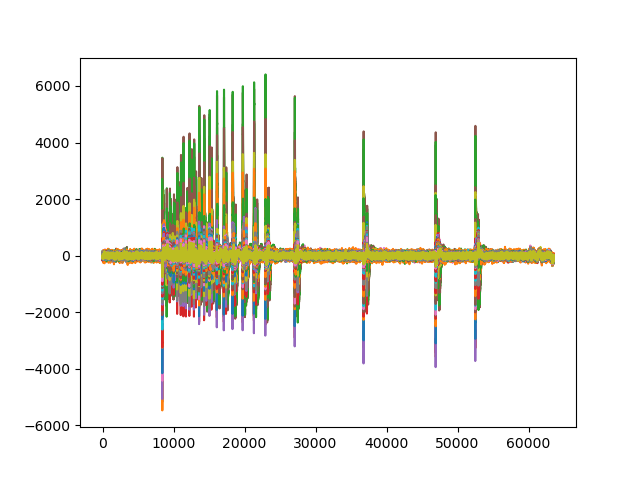

In [75]:
plt.figure()
plt.plot(event);


In [84]:
detected_events['duration']= detected_events['intervals_end']-detected_events['intervals_start']

In [85]:
plt.plot(detected_events['duration']

SyntaxError: unexpected EOF while parsing (3492819247.py, line 1)

In [ ]:
region = 'ctx'
plt.figure(figsize=(10,3))
subsplot = 1
plt.plot(np.arange(0,len(filt[::subsplot]))*(1/(subsampling_rate/subsplot)),filt[::subsplot,regions==region],alpha=0.3)
plt.show()
try:
    detected_events = pd.read_csv('../data/R1648H/detected_events/'+'detected_events_'+str(region)+'_'+file_name)
    [plt.axvspan(na(detected_events.iloc[i].intervals_start),na(detected_events.iloc[i].intervals_end),alpha=0.2) for i in range(len(detected_events))];
except:
    print('Not detected yet')